In [1]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [2]:
import os
import pathlib

**EXTRACTION**

In [3]:
def list_files(path, dict_images=None):
    if dict_images is None:
        dict_images = {
            "file_path": [],
            "dir_name": [], 
            "file_name": [],
            "format": [],
            "resolution": [],
            "ratio": [],
            "mode": [],
            "file_size_mb": []
        }
    
    for entry in os.scandir(path): 
        if entry.is_file():

            if not entry.name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            
            actual_dir = pathlib.Path(entry.path).parent.name
            file_name = os.path.splitext(entry.name)[0]
            file_size = os.path.getsize(entry.path)

            try:
                with Image.open(entry.path) as img:
                    img_width, img_height = img.size
                    if img_height == 0:
                        continue

                    img_format, img_mode, img_resolution, img_ratio = img.format, img.mode, img_width*img_height, round(img_width/img_height, 2)

                    dict_images["file_path"].append(entry.path)
                    dict_images["dir_name"].append(actual_dir)
                    dict_images["file_name"].append(file_name)
                    dict_images["format"].append(img_format)
                    dict_images["resolution"].append(img_resolution)
                    dict_images["ratio"].append(img_ratio)
                    dict_images["mode"].append(img_mode)
                    dict_images["file_size_mb"].append(file_size / (1024**2))

            except Exception as e:
                continue

        elif entry.is_dir():
            dict_images =list_files(entry.path, dict_images)

    return dict_images

In [ ]:
directory_classification = 'C:\\Users\\castr\\OneDrive\\Desktop\\proyecto_ia\\proyecto\\data\\cat_dog_class'
dict_images_classification = list_files(directory_classification)
df_images_classification = pd.DataFrame(dict_images_classification)

In [ ]:
directory_reid_cat = 'C:\\Users\\castr\\OneDrive\\Desktop\\proyecto_ia\\proyecto\\data\\reid_cat'
dict_images_reid_cat = list_files(directory_reid_cat)
df_images_reid_cat = pd.DataFrame(dict_images_reid_cat)

In [ ]:
directory_reid_dog = 'C:\\Users\\castr\\OneDrive\\Desktop\\proyecto_ia\\proyecto\\data\\reid_dog'
dict_images_reid_dog = list_files(directory_reid_dog)
df_images_reid_dog = pd.DataFrame(dict_images_reid_dog)

**EDA CLASSIFICATION**

In [ ]:
df_images_classification['dir_name'].value_counts()

dir_name
Cat    12499
Dog    12499
Name: count, dtype: int64

In [ ]:
df_images_classification['mode'].value_counts()

mode
RGB     24931
P          57
L           5
CMYK        3
RGBA        2
Name: count, dtype: int64

In [ ]:
df_images_classification['format'].value_counts()

format
JPEG    24769
BMP       173
GIF        51
PNG         4
PSD         1
Name: count, dtype: int64

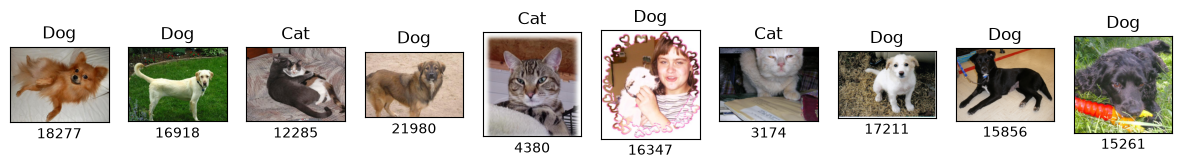

In [ ]:
def plot_resolution_vs_file_size(df, n=5, seed=None):
    df_sampled = df.sample(n=n, random_state=seed)
    plt.figure(figsize=(15, 4))
    for i, (_, row) in zip(range(n), df_sampled.iterrows()):
        title = df_sampled['dir_name'].iloc[i]
        with Image.open(row['file_path']) as img:
            plt.subplot(1, n, i+1)
            plt.imshow(img)
            plt.title(title)
            plt.xlabel(_)
            plt.xticks([])
            plt.yticks([])
    
plot_resolution_vs_file_size(df_images_classification,n=10)

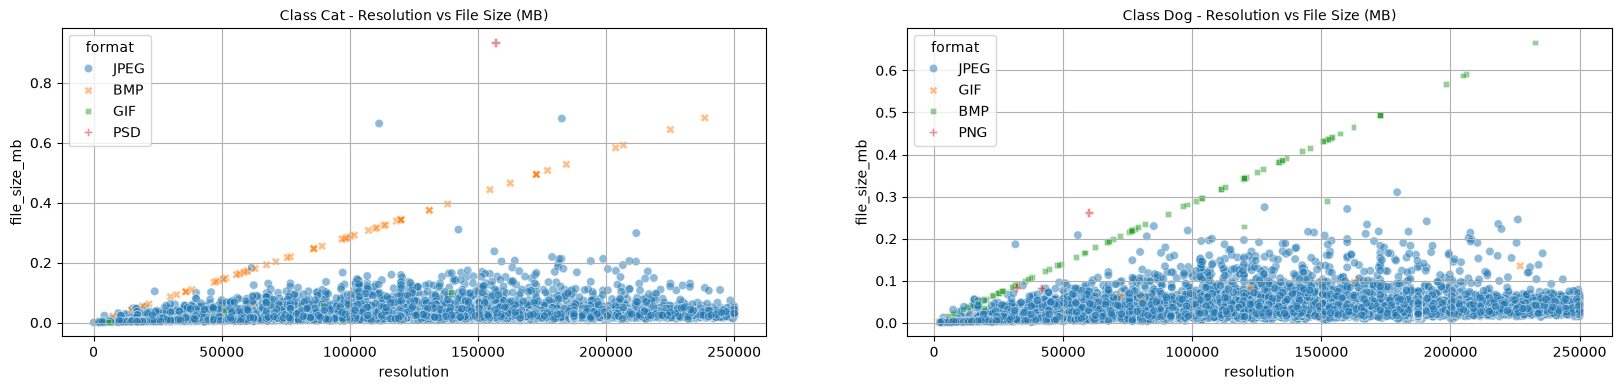

In [ ]:
classes_classification = df_images_classification['dir_name'].unique()
plt.figure(figsize=(20, 4))
for i, class_name in enumerate(classes_classification):
    plt.subplot(1, len(classes_classification), i+1)
    plt.title(f"Class {class_name} - Resolution vs File Size (MB)", fontsize=10, color='black')
    sns.scatterplot(
        data=df_images_classification[df_images_classification['dir_name'] == class_name],
        x='resolution', 
        y='file_size_mb',
        hue='format', 
        style='format',
        alpha=0.5
    )
    plt.grid()
plt.show()

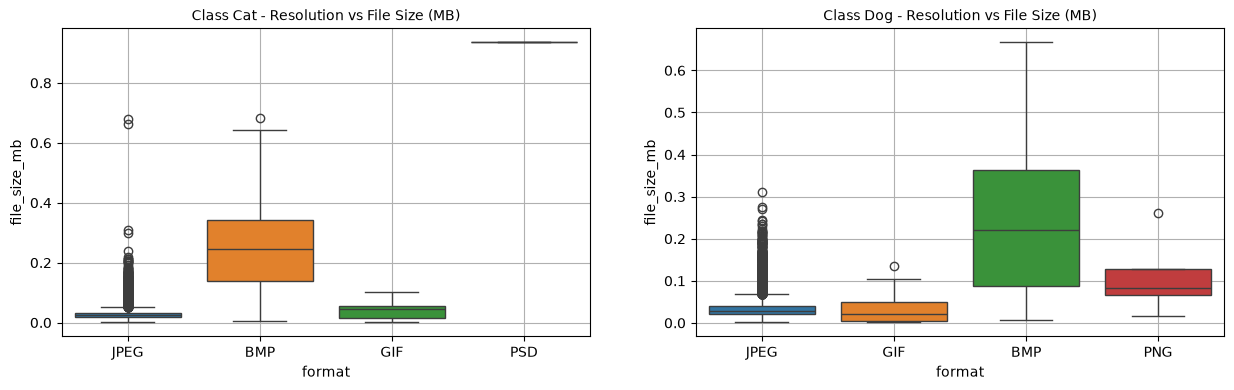

In [ ]:
plt.figure(figsize=(15, 4))
for i, class_name in enumerate(classes_classification):
    plt.subplot(1, len(classes_classification), i+1)
    plt.title(f"Class {class_name} - Resolution vs File Size (MB)", fontsize=10, color='black')
    sns.boxplot(
        data=df_images_classification[df_images_classification['dir_name'] == class_name],
        y='file_size_mb',
        x='format',
        hue='format'
    )
    plt.grid()
plt.show()

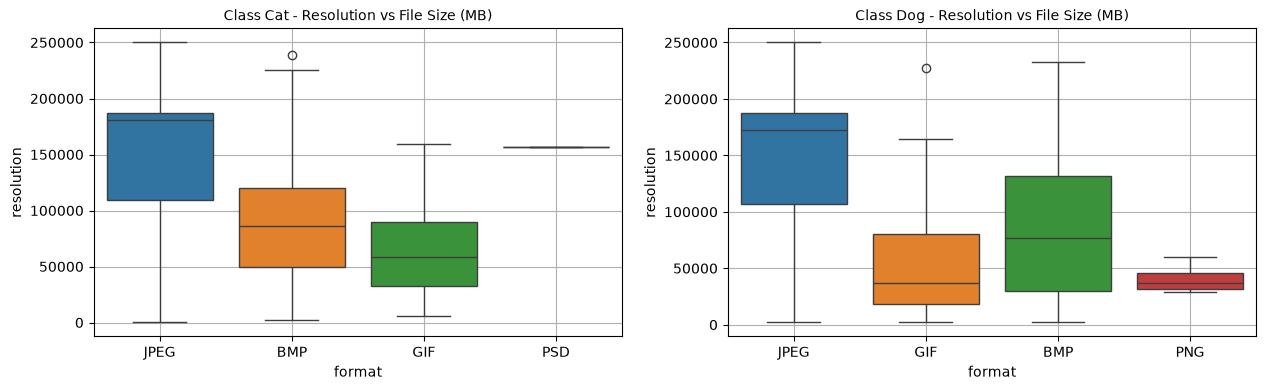

In [ ]:
plt.figure(figsize=(15, 4))
for i, class_name in enumerate(classes_classification):
    plt.subplot(1, len(classes_classification), i+1)
    plt.title(f"Class {class_name} - Resolution vs File Size (MB)", fontsize=10, color='black')
    sns.boxplot(
        data=df_images_classification[df_images_classification['dir_name'] == class_name],
        y='resolution',
        x='format',
        hue='format'
    )
    plt.grid()
plt.show()

In [ ]:
df_images_classification_modified = df_images_classification.copy()
df_images_classification_modified['orientation'] = df_images_classification_modified['ratio'].apply(
    lambda x: 'square' if 0.97 <= x <= 1.03 else 'vertical' if x < 1 else 'horizontal'
)

In [ ]:
conteo_groupby = df_images_classification_modified.groupby(['dir_name', 'orientation'], group_keys=False).size()
conteo_class_orientation = pd.DataFrame(conteo_groupby)

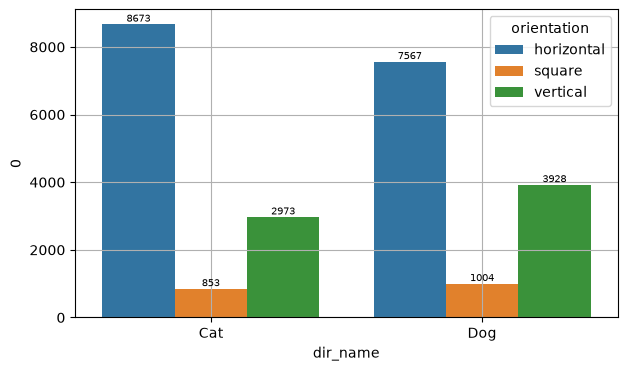

In [ ]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=conteo_class_orientation, y=0, x='dir_name', estimator='sum', hue='orientation')
for container in ax.containers:
    ax.bar_label(container, fontsize=7.5)
plt.grid()
plt.show()

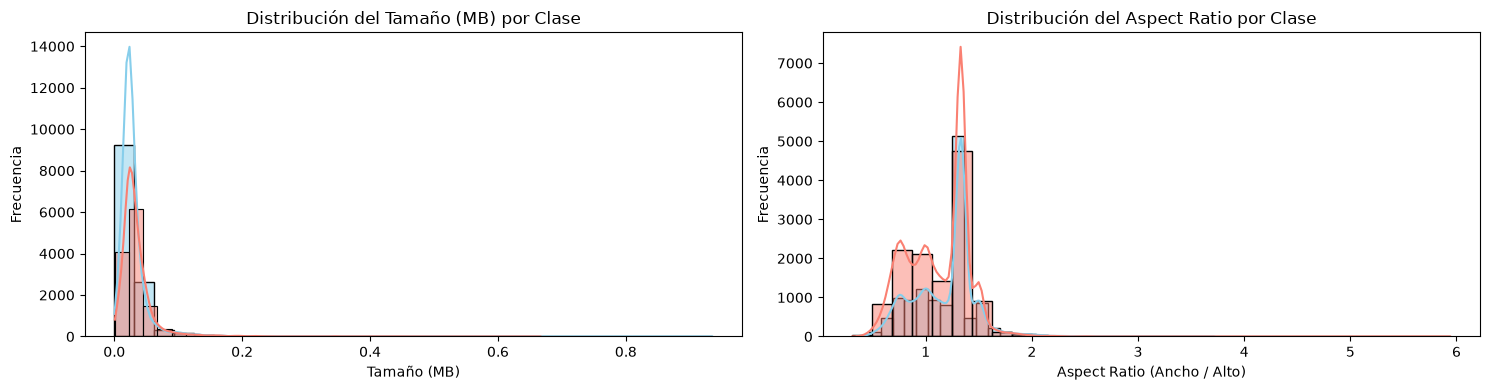

In [ ]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_images_classification[df_images_classification['dir_name'] == 'Cat']['file_size_mb'], bins=30, kde=True, color='skyblue', alpha=0.5)
sns.histplot(df_images_classification[df_images_classification['dir_name'] == 'Dog']['file_size_mb'], bins=30, kde=True, color='salmon', alpha=0.5)
plt.title('Distribución del Tamaño (MB) por Clase')
plt.xlabel('Tamaño (MB)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df_images_classification[df_images_classification['dir_name'] == 'Cat']['ratio'], bins=30, kde=True, color='skyblue', alpha=0.5)
sns.histplot(df_images_classification[df_images_classification['dir_name'] == 'Dog']['ratio'], bins=30, kde=True, color='salmon', alpha=0.5)
plt.title('Distribución del Aspect Ratio por Clase')
plt.xlabel('Aspect Ratio (Ancho / Alto)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

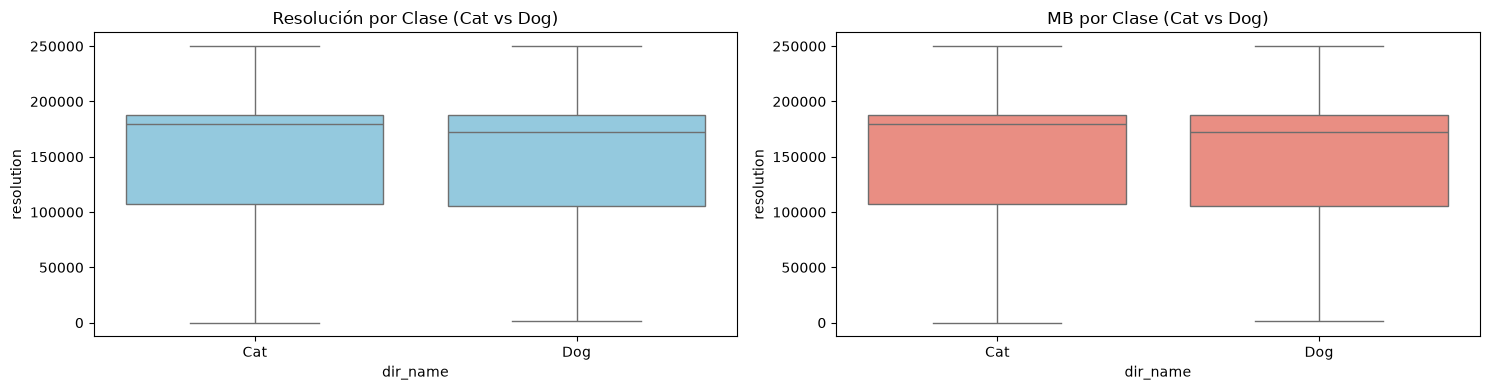

In [ ]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x='dir_name', y='resolution', data=df_images_classification, color='skyblue')
plt.title('Resolución por Clase (Cat vs Dog)')
    
plt.subplot(1, 2, 2)  
sns.boxplot(x='dir_name', y='resolution', data=df_images_classification, color='salmon')
plt.title('MB por Clase (Cat vs Dog)')

plt.tight_layout()
plt.show()

**EDA REID CATS**

In [ ]:
df_images_reid_cat.head()

,file_path,dir_name,file_name,format,resolution,ratio,mode,file_size_mb
0,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,0001,0001_000,JPEG,7990272,1.33,RGB,0.795949
1,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,0001,0001_001,JPEG,7990272,1.33,RGB,0.730849
2,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,0001,0001_002,JPEG,7990272,1.33,RGB,0.748957
3,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,0001,0001_003,JPEG,7990272,1.33,RGB,0.795803
4,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,0001,0001_004,JPEG,7990272,1.33,RGB,0.753259


In [ ]:
df_images_reid_cat_modified = df_images_reid_cat.copy()

**manejo de archivos anidados**

In [ ]:
df_images_reid_cat_modified['dir_name'] = df_images_reid_cat_modified['dir_name'].apply(lambda x: x.split('_')[0] if '_' in x else x)
df_images_reid_cat_modified['dir_name'] = df_images_reid_cat_modified['dir_name'].apply(lambda x: int(x))

In [ ]:
print(f"El promedio de fotos por individuo es de: {df_images_reid_cat_modified['dir_name'].value_counts().mean():.0f}")

El promedio de fotos por individuo es de: 26


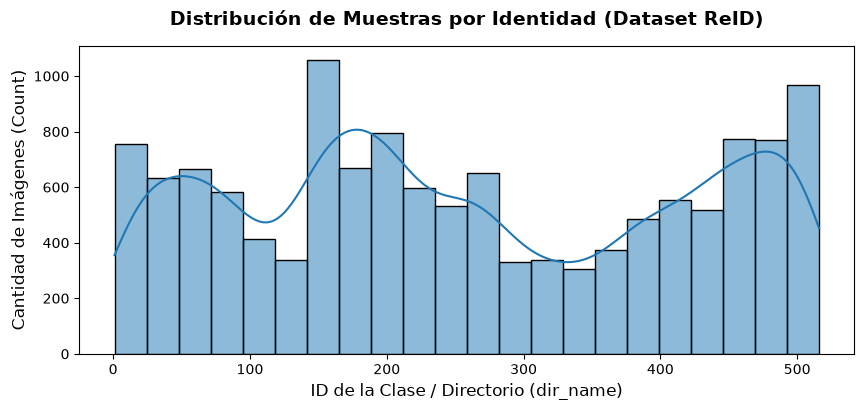

In [ ]:
plt.figure(figsize=(10, 4))
plt.title('Distribución de Muestras por Identidad (Dataset ReID)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('ID de la Clase / Directorio (dir_name)', fontsize=12)
plt.ylabel('Cantidad de Imágenes (Count)', fontsize=12)
sns.histplot(data=df_images_reid_cat_modified, x='dir_name', kde=True)
plt.show()

plt.figure(figsize=())